<a href="https://colab.research.google.com/github/AhmedAwad215/ML-Projects/blob/main/Salary_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/Salary_dataset.csv')

In [3]:
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [4]:
df.describe()

,Unnamed: 0,YearsExperience,Salary
count,30.000000,30.000000,30.000000
mean,14.500000,5.413333,76004.000000
std,8.803408,2.837888,27414.429785
min,0.000000,1.200000,37732.000000
25%,7.250000,3.300000,56721.750000
50%,14.500000,4.800000,65238.000000
75%,21.750000,7.800000,100545.750000
max,29.000000,10.600000,122392.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes


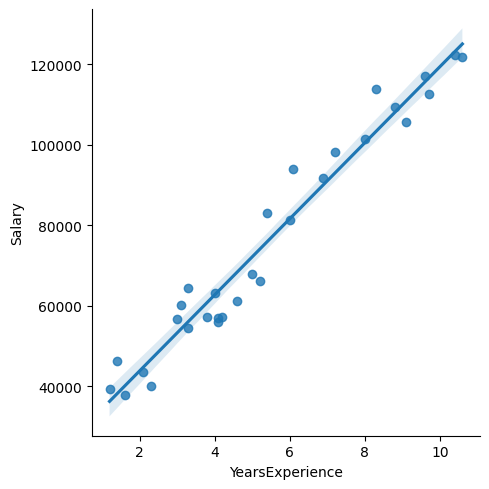

In [6]:
sns.lmplot(x ='YearsExperience',y ='Salary',data=df)

In [7]:
X = df[['YearsExperience']]
y = df['Salary']

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [12]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [14]:
y_pred = model.predict(X_test)


In [29]:
from sklearn import metrics


print('MAE:', metrics.mean_absolute_error(y_test, y_pred))

print('MSE:', metrics.mean_squared_error(y_test, y_pred))

print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))


MAE: 5146.886734888229
MSE: 39139215.999588534
RMSE: 6256.134269625975


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


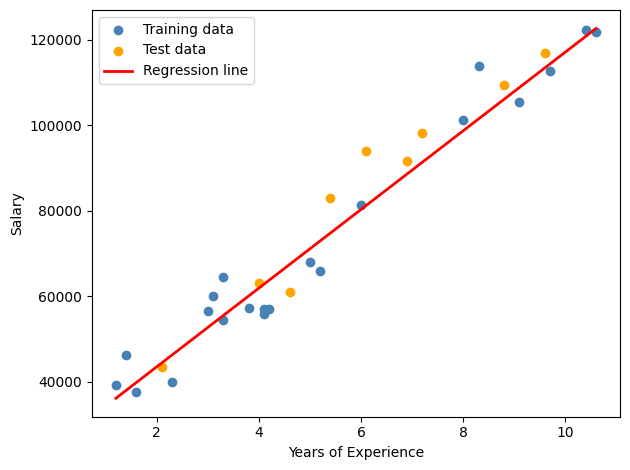

In [30]:
plt.scatter(X_train, y_train, color='steelblue', label='Training data')
plt.scatter(X_test, y_test, color='orange', label='Test data')
xs = np.linspace(X.min().values[0], X.max().values[0], 100).reshape(-1,1)
plt.plot(xs, model.predict(xs), color='red', linewidth=2, label='Regression line')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.tight_layout()

In [38]:
import gradio as gr

def predict_Salary(years_experience):

    employee_data = [[years_experience]]

    prediction = model.predict(employee_data)[0]

    return prediction


demo = gr.Interface(
    fn=predict_Salary,
    inputs=gr.Number(
        label="Years of Experience",
        value=1
    ),
    outputs=gr.Number(
        label="Predicted Salary"
    ),
    title="Salary Prediction",
    description="Enter the number of years of experience to predict the salary."
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1c6a9ba5c7022f79c3.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
